# Mastering DBSCAN: Density-Based Spatial Clustering

**DBSCAN** groups together points that are closely packed together (points with many nearby neighbors), marking points that lie alone in low-density regions as outliers (noise).



## 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

## 2. Fetching the Real-Time Dataset
We are pulling the **Wholesale Customers** dataset directly from the UCI Machine Learning Repository via URL. We will try to cluster clients based on their annual spending on **Milk** and **Grocery**.

In [2]:
# Fetch dataset directly from UCI repository URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

# Display the first few rows
display(df.head())

# We will select 'Milk' and 'Grocery' for 2D visualization purposes
X = df[['Milk', 'Grocery']]

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3. Data Preprocessing & Scaling
Because DBSCAN relies on the concept of "distance" (Epsilon), features with larger numerical ranges will dominate the calculation. **Standardization is mandatory.**

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Data Sample:")
print(X_scaled[:5])

Scaled Data Sample:
[[ 0.52356777 -0.04111489]
 [ 0.54445767  0.17031835]
 [ 0.40853771 -0.0281571 ]
 [-0.62401993 -0.3929769 ]
 [-0.05239645 -0.07935618]]


## 4. Finding Optimal Epsilon (eps) using the K-Distance Graph
To find the best `eps` value, we calculate the distance to the K-th nearest neighbor for every point. 
A good rule of thumb for `min_samples` is `2 * features`. Since we have 2 features, we use `min_samples = 4`.

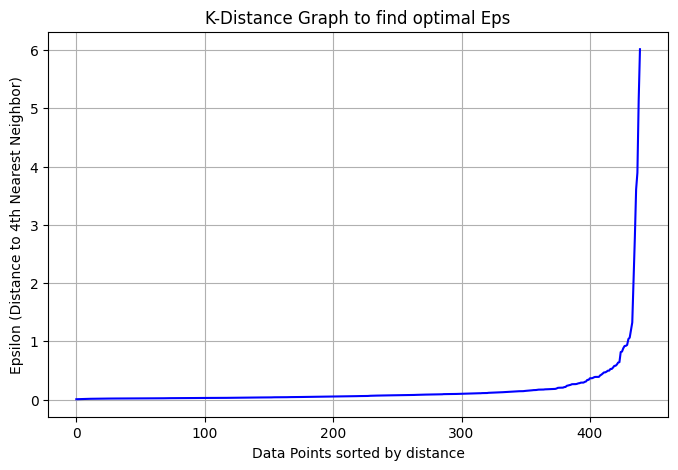

Notice the 'elbow' or sharp upward curve around Epsilon = 0.5 or 0.6.


In [4]:
# We use k=4 (which maps to n_neighbors=4)
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to the 4th nearest neighbor
# (Index 3 represents the 4th neighbor since Index 0 is the point itself)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='blue')
plt.title('K-Distance Graph to find optimal Eps')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon (Distance to 4th Nearest Neighbor)')
plt.grid(True)
plt.show()

print("Notice the 'elbow' or sharp upward curve around Epsilon = 0.5 or 0.6.")

## 5. Training the DBSCAN Model
Based on the K-distance graph, we will select `eps = 0.5` and `min_samples = 4`.

In [6]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
clusters = dbscan.fit_predict(X_scaled)

# Add the cluster labels back to our original dataframe
df['Cluster_Label'] = clusters

# Note: -1 represents NOISE (outliers)
print("Cluster Labels generated:")
print(df['Cluster_Label'].value_counts())

Cluster Labels generated:
Cluster_Label
 0    417
-1     18
 1      5
Name: count, dtype: int64


## 6. Visualizing the Clusters & Noise
Let's visualize the groups. We will plot the normal clusters in various colors, and explicitly highlight the noise points (`-1`) in **Red**.

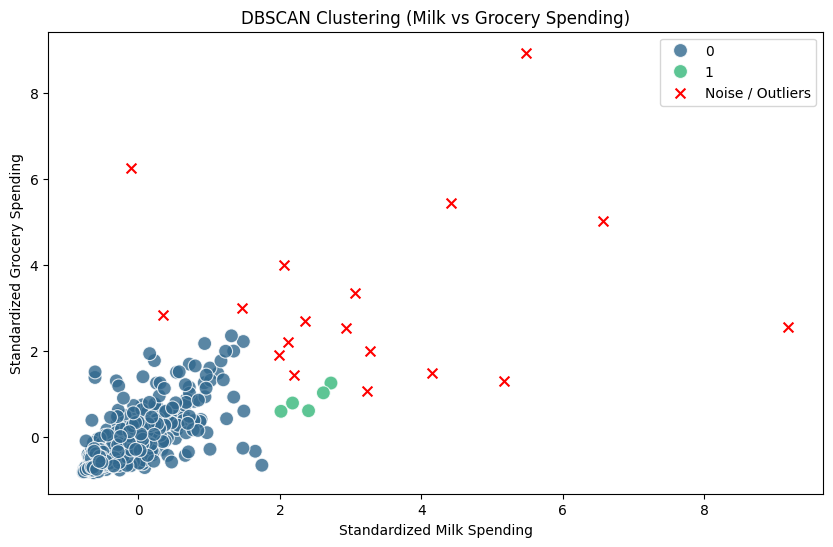

In [7]:
plt.figure(figsize=(10, 6))

# Scatter plot for points belonging to a valid cluster
sns.scatterplot(
    x=X_scaled[clusters != -1, 0], 
    y=X_scaled[clusters != -1, 1], 
    hue=clusters[clusters != -1], 
    palette='viridis', 
    s=100, 
    alpha=0.8, 
    legend='full'
)

# Scatter plot for NOISE points (Label = -1)
plt.scatter(
    X_scaled[clusters == -1, 0], 
    X_scaled[clusters == -1, 1], 
    c='red', 
    s=50, 
    label='Noise / Outliers',
    marker='x'
)

plt.title('DBSCAN Clustering (Milk vs Grocery Spending)')
plt.xlabel('Standardized Milk Spending')
plt.ylabel('Standardized Grocery Spending')
plt.legend()
plt.show()

## 7. Model Evaluation
In unsupervised learning, we don't have "Ground Truth" labels to calculate Accuracy. Instead, we use metrics like the **Silhouette Score** which measures how similar an object is to its own cluster compared to other clusters. 

*(Note: Silhouette score ranges from -1 to 1. Higher is better.)*

In [8]:
# We exclude noise points (-1) from the silhouette score calculation to get a true representation of cluster density
valid_mask = clusters != -1
if len(set(clusters[valid_mask])) > 1: # Requires at least 2 clusters to calculate
    sil_score = silhouette_score(X_scaled[valid_mask], clusters[valid_mask])
    print(f"Silhouette Score (excluding noise): {sil_score * 100:.2f}%")
else:
    print("Not enough distinct clusters generated to calculate Silhouette Score.")

Silhouette Score (excluding noise): 63.23%


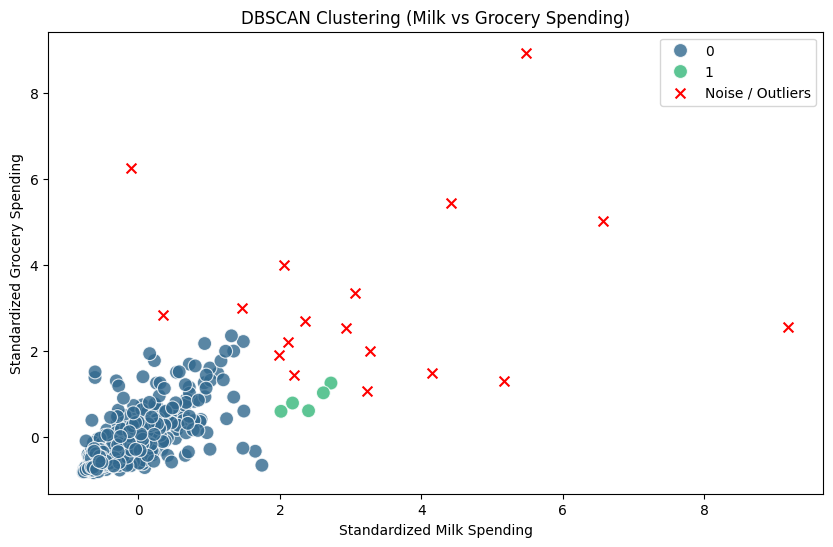

In [9]:
plt.figure(figsize=(10, 6))

# Scatter plot for points belonging to a valid cluster (Label >= 0)
sns.scatterplot(
    x=X_scaled[clusters != -1, 0], 
    y=X_scaled[clusters != -1, 1], 
    hue=clusters[clusters != -1], 
    palette='viridis', 
    s=100, 
    alpha=0.8, 
    legend='full'
)

# Scatter plot for NOISE points (Label == -1)
plt.scatter(
    X_scaled[clusters == -1, 0], 
    X_scaled[clusters == -1, 1], 
    c='red', 
    s=50, 
    label='Noise / Outliers',
    marker='x'
)

plt.title('DBSCAN Clustering (Milk vs Grocery Spending)')
plt.xlabel('Standardized Milk Spending')
plt.ylabel('Standardized Grocery Spending')
plt.legend()
plt.show()